# Appendix A Fig A1

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import sys
import metpy
import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import metpy.calc as mpcalc
import pandas as pd
from netCDF4 import Dataset
import pyproj
import os
import glob
from datetime import datetime
import seaborn as sns
import netCDF4
from netCDF4 import Dataset
from metpy.units import units
import dask
import pytz
from scipy.stats import circmean

import xarray as xr
from shapely import Polygon
import regionmask
import geopandas as gpd
import logging
import dask
from dask.distributed import Client
from dask import delayed
import functools
import zipfile
import tempfile
import wradlib as wrl
sys.path.append(os.path.join(r"/home/563/ac9768/GBR/scripts/Paper_figures")) 

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from dask_setup import setup_dask_client 
from dask_setup import recommend_chunks
client, cluster, dask_tmp = setup_dask_client(mode="interactive", workload_type="cpu") # 'io','mixed'(io and cpu=computation), 'auto' (inferred from ds)

INFO     [client] Interactive cluster mode — using already-allocated nodes
INFO     [multinode] Interactive cluster: single node, using LocalCluster (node=gadi-cpu-bdw-0074.gadi.nci.org.au)
INFO     [client] Starting Dask client setup (workload_type=cpu | environment=jupyter)
INFO     [resources] Resources detected via PBS (total_cores=28 | total_mem_gib=252.0)


INFO     [client] Temp/spill dir: /jobfs/172074530.gadi-pbs/dask-948928
INFO     [client] Workers: 28 | threads/worker: 1 | processes: True
INFO     [client] Mem: total ~252.0 GiB | usable ~202.0 GiB | per-worker ~7.2 GiB
INFO     [client] Compression: spill=auto | comm=False
INFO     [client] Dask client ready


[setup_dask_client] Configuration summary
temp/spill dir: /jobfs/172074530.gadi-pbs/dask-948928
Workers: 28 | threads/worker: 1 | processes: True
Memory: total ~252.0 GiB | usable ~202.0 GiB | per-worker ~7.2 GiB
Compression: spill=auto | comm=False


In [5]:
barra_towns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa-winds_towns.nc", engine="h5netcdf",chunks="auto").sel(time=slice('1990-01-01','2020-02-02'))
barra_cairns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa-winds_cairns.nc", engine="h5netcdf",chunks="auto").sel(time=slice('1990-01-01','2020-02-02'))
barra_willis = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa-winds_willis.nc", engine="h5netcdf",chunks="auto").sel(time=slice('1990-01-01','2020-02-02'))

In [6]:
def utc_to_lst_shift(ds, longitude_center: float):
    """
    Shift xarray data from UTC to Local Solar Time by offsetting the 
    time coordinate. Adds the LST offset to time labels directly —
    does NOT roll/wrap data values.

    Args:
        ds:               xarray Dataset or DataArray with a 'time' dimension.
        longitude_center: Representative longitude of the region (decimal degrees).

    Returns:
        Dataset/DataArray with time coordinate relabelled to LST.
    """
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    ds_lst = ds.assign_coords(time=ds.time + offset)
    return ds_lst

In [7]:
def wind_times(barra_regime_ds: xr.Dataset, longitude_center: float):
    """
    Classify wind direction at LST solar noon (hour=12), then assign
    all hours of that day to the same wind regime.

    Args:
        barra_regime_ds:  xarray Dataset with 'wind_dir' and 'time' dimension.
        longitude_center: Representative longitude for LST conversion.

    Returns:
        ne, se, sw, nw: arrays of datetime64 timestamps (all hours) 
                        belonging to each wind regime day.
    """
    # 1. Shift full dataset to LST
    ds_lst = utc_to_lst_shift(barra_regime_ds, longitude_center)

    # 2. Extract wind_dir and compute (needed for boolean indexing)
    winds = ds_lst.wind_dir.compute()

    # 3. Select only solar noon (LST hour=12) for regime classification
    winds_noon = winds.sel(time=winds.time.dt.hour == 12)

    # 4. Classify noon wind direction → get dates (not full timestamps)
    ne_dates = winds_noon.time.values[(winds_noon.values >= 0)   & (winds_noon.values <= 90)]
    se_dates = winds_noon.time.values[(winds_noon.values > 90)   & (winds_noon.values <= 180)]
    sw_dates = winds_noon.time.values[(winds_noon.values > 180)  & (winds_noon.values <= 270)]
    nw_dates = winds_noon.time.values[(winds_noon.values > 270)  & (winds_noon.values <= 360)]

    # 5. Convert noon timestamps → date-only for day matching
    def noon_to_all_hours(regime_noon_times):
        """Given noon timestamps, return all LST timestamps on those days."""
        regime_dates = set(
            pd.Timestamp(t).date() for t in regime_noon_times
        )
        all_times = pd.DatetimeIndex(winds.time.values)
        mask = all_times.normalize().map(lambda d: d.date() in regime_dates)
        return winds.time.values[mask]

    ne_lst = noon_to_all_hours(ne_dates)
    se_lst = noon_to_all_hours(se_dates)
    sw_lst = noon_to_all_hours(sw_dates)
    nw_lst = noon_to_all_hours(nw_dates)

    # 6. Convert LST timestamps back to UTC by subtracting the offset
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    # ds_lst = ds.assign_coords(time=ds.time + offset)

    
    # offset_hours = round(longitude_center * 4 / 60)
    # offset = np.timedelta64(offset_hours, 'h')

    ne = ne_lst - offset
    se = se_lst - offset
    sw = sw_lst - offset
    nw = nw_lst - offset

    return ne, se, sw, nw


# --- Usage ---
lon_towns  = (145.12054 + 147.9812)  / 2  # ≈ 146.55°E
lon_cairns = (144.27374 + 147.09222) / 2  # ≈ 145.68°E
lon_willis = (148.55927 + 151.36993) / 2

ne_towns,  se_towns,  sw_towns,  nw_towns  = wind_times(barra_towns,  lon_towns)
ne_cairns, se_cairns, sw_cairns, nw_cairns = wind_times(barra_cairns, lon_cairns)
ne_willis, se_willis, sw_willis, nw_willis = wind_times(barra_willis, lon_willis)

# open Cairns station data

In [8]:
def UTC_to_LST(ds, timezone): # longitude
    ds = ds.copy()
    # Convert to pandas datetime in UTC
    time_objects_utc = pd.to_datetime(ds['time'].values).tz_localize('UTC')
    
    # Convert to local standard time using pytz
    local_timezone = pytz.timezone(timezone)
    time_objects_local = time_objects_utc.tz_convert(local_timezone).tz_localize(None)
    # Assign back to ds['time'], remove timezone info if desired:
    ds['time'] = time_objects_local#.tz_localize(None)
    return ds

In [9]:
fp = '/g/data/w40/clv563/BoM_data/AWS-data-QLD.nc'
# station ID's can be found on the BoM website: http://www.bom.gov.au/catalogue/observations/about-weather-observations.shtml#maps
ds_stations = xr.open_dataset(fp, engine="h5netcdf")
ds_LST = UTC_to_LST(ds_stations,'Australia/Sydney')
jfma_data = ds_LST.sel(time=ds_LST.time.dt.month.isin([1,2,3,4]))

# cairns ID = 31011 --> station=21; townsville ID = 32040 --> station=30
ds_cairns_wd = jfma_data["wdir"].sel(station=21)* units("degrees")
ds_cairns_ws = jfma_data["wspd"].sel(station=21)* (1000/(60*60)) *  units("m/s")

In [10]:
def wind_masks(ds_wdir,ds_wdspd):
    calm_mask = xr.where(ds_wdspd==0*units('m/s'), np.nan, ds_wdspd)
    wdir_mask = xr.where(np.isnan(calm_mask), np.nan, ds_wdir)
    return wdir_mask,calm_mask

In [11]:
def calc_circ_mean_wd(ds, **kwargs):
    radian = np.deg2rad(ds)
    circmean_ds = circmean(radian,high=(2*np.pi),low=0,nan_policy='omit', **kwargs)
    return np.rad2deg(circmean_ds)

In [12]:
def wind_masks(ds_wdir, ds_wdspd):
    calm_mask = xr.where(ds_wdspd == 0*units('m/s'), np.nan, ds_wdspd)
    wdir_mask = xr.where(np.isnan(calm_mask), np.nan, ds_wdir)
    return wdir_mask, calm_mask

def calc_circ_mean_wd(ds, **kwargs):
    radian = np.deg2rad(ds)
    circmean_ds = circmean(radian, high=(2*np.pi), low=0, nan_policy='omit', **kwargs)
    return np.rad2deg(circmean_ds)

regimes = {
    'ne': ne_cairns,
    'se': se_cairns,
    'sw': sw_cairns,
    'nw': nw_cairns,   
}
ds_cairns_wd = ds_cairns_wd.drop_duplicates(dim='time')
ds_cairns_ws = ds_cairns_ws.drop_duplicates(dim='time')

results = {}
for regime, times in regimes.items():
    unique_times = xr.DataArray(times).drop_duplicates(dim='dim_0').values
    
    wd_sel = ds_cairns_wd.sel(time=unique_times, method='nearest', )
    ws_sel = ds_cairns_ws.sel(time=unique_times, method='nearest', )

    wd, ws = wind_masks(wd_sel, ws_sel)

    hourly_ws = ws.groupby('time.hour').mean(skipna=True)

    hourly_wd = xr.apply_ufunc(
        calc_circ_mean_wd,
        wd.groupby('time.hour'),
        input_core_dims=[['time']],
        vectorize=True,
    )

    results[regime] = {
        'wind_speed': hourly_ws,
        'wind_dir':   hourly_wd,
    }

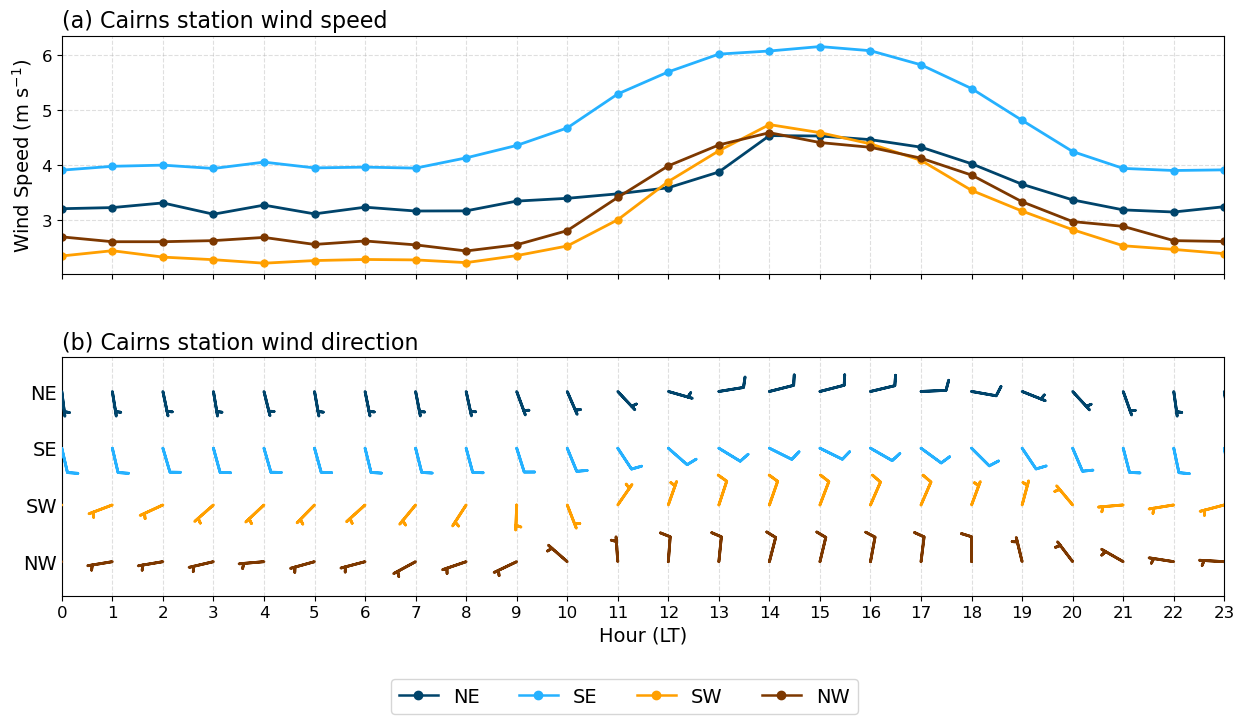

In [13]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from matplotlib.patches import FancyArrowPatch

SMALL  = 12
MEDIUM = 14
LARGE  = 16

# colors
ne_c = '#00446B' # '#0072B2'
se_c = '#25B1FF' ##9DDCFF'
sw_c = '#FF9F00' #'#D55E00'
nw_c = '#7D3800' #'#F0E442'
regime_colors = {
        "NE": ne_c,
        "SE": se_c,
        "SW": sw_c,
        "NW": nw_c,
    }
hours = np.arange(0, 24)

barb_rows  = {'NE': 3, 'SE': 2, 'SW': 1, 'NW': 0}
barb_y_ticks  = [0, 1, 2, 3]
barb_y_labels = ['NW', 'SW', 'SE', 'NE']

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
fig.subplots_adjust(hspace=0.35, bottom=0.18)

# ── (a) Wind Speed ──────────────────────────────────────────────────────────
ax1 = axes[0]
for regime, color in regime_colors.items():
    ws = results[regime.lower()]['wind_speed']
    ax1.plot(hours, ws.values, color=color, linewidth=2,
             marker='o', markersize=5, label=regime)

ax1.set_ylabel('Wind Speed (m s$^{-1}$)', fontsize=MEDIUM)
ax1.set_title('(a) Cairns station wind speed', loc='left', fontsize=LARGE)
ax1.set_xlim(0, 23)
ax1.set_xticks(hours)
ax1.tick_params(axis='both', labelsize=SMALL)
ax1.grid(True, linestyle='--', alpha=0.4)

# ── (b) Wind Direction (barbs) ───────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('white')
for regime, color in regime_colors.items():
    wd     = results[regime.lower()]['wind_dir']
    ws     = results[regime.lower()]['wind_speed']
    y_pos  = barb_rows[regime]
    wd_rad = np.deg2rad(wd.values)
    u = -np.sin(wd_rad) * ws.values
    v = -np.cos(wd_rad) * ws.values

    ax2.barbs(hours, np.full(len(hours), y_pos), u, v,
              length=6, linewidth=2, color=color,
              barb_increments=dict(half=2.5, full=5, flag=25),
              flip_barb=True, zorder=3)

ax2.set_yticks(barb_y_ticks)
ax2.set_yticklabels(barb_y_labels, fontsize=MEDIUM)
ax2.set_ylim(-0.6, 3.6)
ax2.set_xlabel('Hour (LT)', fontsize=MEDIUM)
ax2.set_title('(b) Cairns station wind direction', loc='left', fontsize=LARGE)
ax2.set_xticks(hours)
ax2.tick_params(axis='x', labelsize=SMALL)
ax2.tick_params(axis='y', length=0)
ax2.grid(True, axis='x', linestyle='--', alpha=0.4)

# ── Legend ───────────────────────────────────────────────────────────────────
legend_handles = [
    mlines.Line2D([], [], color=color, marker='o', markersize=6,
                  linewidth=1.8, label=regime)
    for regime, color in regime_colors.items()
]
fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           frameon=True, fontsize=MEDIUM, bbox_to_anchor=(0.5, 0.02),
           title_fontsize=MEDIUM)

fig.savefig('/home/563/ac9768/GBR/scripts/Chapman_etal_2026preprint/f12_A3.png',
                bbox_inches='tight', dpi=300)
plt.show()

